# Projet fin de module – Partie I : Données tabulaires
## Dataset : Titanic | Pipeline scikit-learn
Auteur : [Nom Étudiant] | EMSI 2025-2026

### Section 1 : Imports et chargement des données

Nous commençons par importer les bibliothèques indispensables pour l'analyse des données, la modélisation et l'évaluation, puis nous chargeons le jeu de données Titanic fourni par Seaborn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Chargement
df = sns.load_dataset('titanic')
print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Section 2 : Inspection initiale et lecture critique

Dans cette section, nous analysons la structure du jeu de données avant toute transformation. Une inspection rigoureuse est indispensable pour identifier les problèmes potentiels (valeurs manquantes, types de variables, déséquilibre de classes) et définir une stratégie de prétraitement cohérente.

=== INFORMATIONS SUR LE DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

=== STATISTIQUES DESCRIPTIVES ===
        

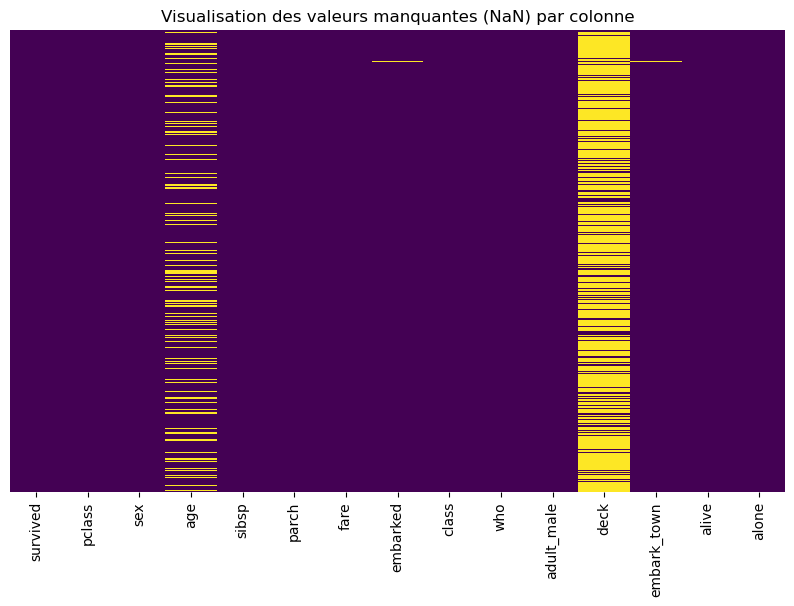


=== VALEURS MANQUANTES (NaN) ===
deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64


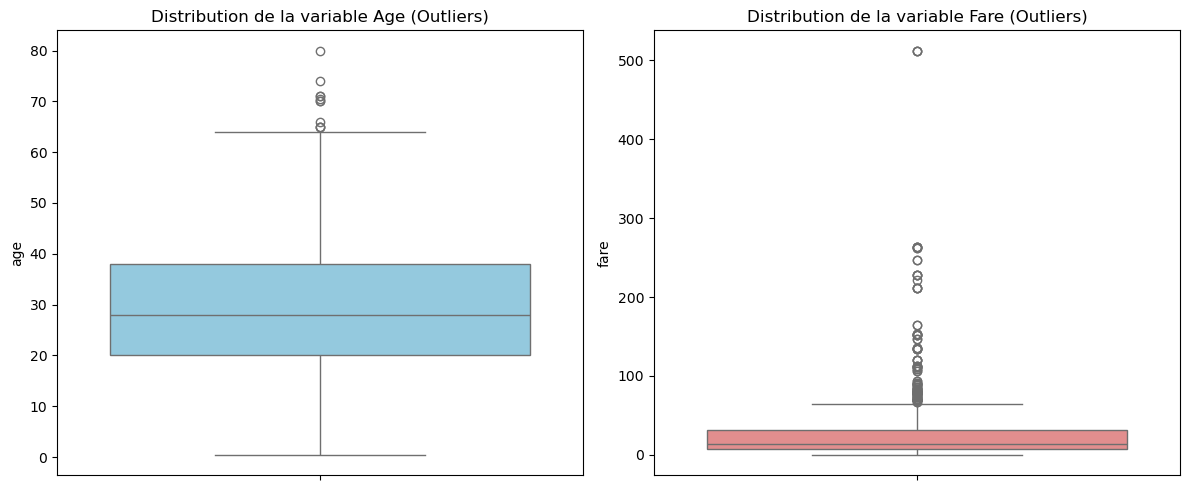

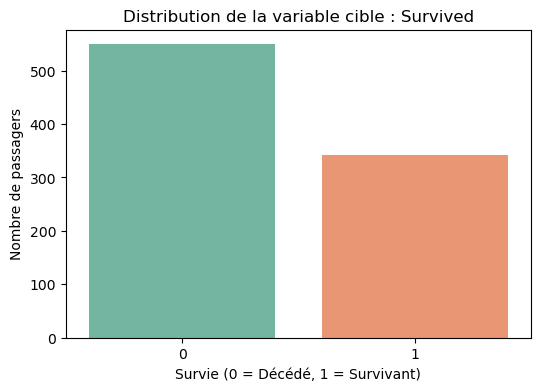

In [2]:
# Types de données et valeurs non-nulles
print("=== INFORMATIONS SUR LE DATASET ===")
df.info()

# Statistiques descriptives pour les variables numériques
print("\n=== STATISTIQUES DESCRIPTIVES ===")
print(df.describe())

# Visualisation des valeurs manquantes (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Visualisation des valeurs manquantes (NaN) par colonne")
plt.show()

# Tableau récapitulatif des NaN
print("\n=== VALEURS MANQUANTES (NaN) ===")
print(df.isnull().sum().sort_values(ascending=False))

# Boxplots pour détecter les valeurs aberrantes (outliers)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y='age', data=df, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution de la variable Age (Outliers)")
sns.boxplot(y='fare', data=df, ax=axes[1], color='lightcoral')
axes[1].set_title("Distribution de la variable Fare (Outliers)")
plt.tight_layout()
plt.show()

# Distribution de la variable cible survived
plt.figure(figsize=(6, 4))
sns.countplot(x='survived', data=df, palette='Set2')
plt.title("Distribution de la variable cible : Survived")
plt.xlabel("Survie (0 = Décédé, 1 = Survivant)")
plt.ylabel("Nombre de passagers")
plt.show()

#### Interprétation de l'inspection initiale

L'analyse exploratoire met en évidence les points méthodologiques suivants :
- **Variables numériques continues** : `age` (177 valeurs manquantes soit ~19.9%) et `fare` (aucune valeur manquante mais forte asymétrie avec des outliers importants). Nous appliquerons une imputation par la médiane (robuste aux outliers) et une normalisation via `StandardScaler`.
- **Variables numériques discrètes** : `sibsp` (frères/sœurs/époux à bord) et `parch` (parents/enfants à bord). Nous choisissons de les conserver telles quelles.
- **Variable ordinale** : `pclass` (classe socio-économique). Bien qu'elle soit représentée par des entiers (1, 2, 3), il existe un ordre naturel où 1ère classe > 2ème classe > 3ème classe. Nous la convertissons en chaîne de caractères pour appliquer un `OrdinalEncoder` avec l'ordre explicite `['3', '2', '1']` pour éviter que l'algorithme ne la traite de manière désordonnée ou comme une variable numérique simple.
- **Variables nominales** : `sex` et `embarked` (port d'embarquement, 2 valeurs manquantes). Nous utiliserons un `OneHotEncoder` avec l'option `drop='first'` pour éliminer la multicolinéarité parfaite (dummy variable trap).
- **Variables à écarter** : Dans cette version Seaborn du dataset, les colonnes à forte cardinalité comme `name` et `ticket` ne sont pas incluses. Le champ `cabin` est représenté par la variable catégorielle `deck` (qui possède 688 valeurs manquantes, soit 77.2%). L'abondance de valeurs manquantes rend l'exploitation directe de `deck` périlleuse. De plus, `alive` est strictement redondante avec la variable cible `survived`. 
- **Risque de data leakage** : Les variables `deck` et `alive` doivent être supprimées/écartées car `alive` est un parfait substitut de la cible et `deck` présente une trop forte colinéarité avec la survie tout en contenant un taux excessif de valeurs manquantes.

### Section 3 : Stratégie de prétraitement (justifiée)

#### 3.1 Justification de la stratégie d'imputation
- **Médiane pour l'âge** : La distribution de l'âge présente une asymétrie et des outliers. La médiane est un indicateur de tendance centrale robuste qui n'est pas influencé par les valeurs extrêmes, contrairement à la moyenne.
- **Mode pour embarked** : Avec seulement 2 valeurs manquantes sur 891, l'imputation par le mode (valeur 'S') est une solution simple et adaptée pour préserver l'information sans introduire de biais significatif.

#### 3.2 Justification de l'encodage
- **OneHotEncoder** : Utilisé pour `sex` et `embarked` car ce sont des variables nominales. L'encodage crée des colonnes binaires indépendantes. L'option `drop='first'` supprime une colonne redondante pour éviter le piège des variables muettes (multicolinéarité).
- **OrdinalEncoder** : Utilisé pour `pclass`. En spécifiant l'ordre explicitement `['3', '2', '1']`, nous reflétons fidèlement le gradient social et économique, ce qui permet aux modèles (en particulier linéaires) de capter l'effet incrémental de la classe sociale.

#### 3.3 Feature Engineering
- **Binarisation de la cabine (`has_cabin`)** : Au lieu de rejeter complètement l'information de la cabine à cause des 77% de valeurs manquantes, nous créons une variable binaire `has_cabin` indiquant si le passager avait une cabine attribuée (valeur non-nulle dans la variable `deck`). Cela traduit l'hypothèse selon laquelle posséder une cabine spécifique est corrélé à un statut socio-économique plus élevé et donc à une plus grande chance de survie.

In [3]:
# Création de la variable binaire has_cabin à partir de deck (qui représente la cabine dans Seaborn)
df['has_cabin'] = df['deck'].notna().astype(int)

# Conversion de pclass en string pour éviter l'erreur d'encodage ordinal sur valeurs numériques non ordonnées en sklearn
df['pclass'] = df['pclass'].astype(str)

# Sélection des colonnes conservées pour la modélisation
features_num = ['age', 'fare', 'sibsp', 'parch']
features_ord = ['pclass']
features_nom = ['sex', 'embarked']

X = df[features_num + features_ord + features_nom + ['has_cabin']].copy()
y = df['survived']

# Division train/test stratifiée
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille X_train : {X_train.shape} | Taille X_test : {X_test.shape}")
print(f"Taux de survie global en Train : {y_train.mean():.2%}")

Taille X_train : (712, 8) | Taille X_test : (179, 8)
Taux de survie global en Train : 38.34%


### Section 4 : Construction des pipelines (ColumnTransformer + Pipeline)

#### Intérêt fondamental du Pipeline et de ColumnTransformer
- **ColumnTransformer** applique des prétraitements ciblés à des sous-ensembles de colonnes (numériques, ordinales, nominales) de manière isolée et cohérente.
- **Pipeline** encapsule tout l'enchaînement (prétraitement et modèle final) en un seul objet. Lors de l'appel à `.fit(X_train, y_train)`, **les statistiques (médiane, moyenne, variance, catégories) sont calculées uniquement sur l'ensemble d'entraînement**. Lors de l'évaluation sur `.predict(X_test)`, ces paramètres pré-calculés sont appliqués sans réajustement. Cela évite rigoureusement le **data leakage** (fuite d'information du test vers le train).

In [4]:
# Pipeline pour les colonnes numériques
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les colonnes catégorielles nominales
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Pipeline pour la colonne catégorielle ordinale
ordinal_transformer = Pipeline([
    ('encoder', OrdinalEncoder(categories=[['3', '2', '1']]))
])

# Association des transformateurs par colonnes
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, features_num),
    ('ord', ordinal_transformer, features_ord),
    ('cat', categorical_transformer, features_nom),
    ('bin', 'passthrough', ['has_cabin'])
])

# Pipeline 1 : Régression Logistique
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline 2 : Random Forest
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

### Section 5 : Validation expérimentale

Nous appliquons une validation croisée stratifiée à 5 plis (`StratifiedKFold`) pour comparer la performance de base des deux modèles, puis nous effectuons une recherche d'hyperparamètres par grille (`GridSearchCV`) pour optimiser chaque modèle.

In [5]:
# Définition de la validation croisée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Évaluation par validation croisée
scores_lr = cross_val_score(pipeline_lr, X_train, y_train, cv=cv, scoring='roc_auc')
scores_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Régression Logistique - AUC-ROC (CV) : {scores_lr.mean():.4f} ± {scores_lr.std():.4f}")
print(f"Random Forest - AUC-ROC (CV)         : {scores_rf.mean():.4f} ± {scores_rf.std():.4f}")

# Optimisation par GridSearch - Régression Logistique
param_grid_lr = {'classifier__C': [0.01, 0.1, 1, 10, 100]}
gs_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_lr.fit(X_train, y_train)
print(f"Meilleur paramètre LR : {gs_lr.best_params_} | AUC-ROC associé : {gs_lr.best_score_:.4f}")

# Optimisation par GridSearch - Random Forest
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10]
}
gs_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train, y_train)
print(f"Meilleur paramètre RF : {gs_rf.best_params_} | AUC-ROC associé : {gs_rf.best_score_:.4f}")

Régression Logistique - AUC-ROC (CV) : 0.8591 ± 0.0228
Random Forest - AUC-ROC (CV)         : 0.8718 ± 0.0129
Meilleur paramètre LR : {'classifier__C': 1} | AUC-ROC associé : 0.8591
Meilleur paramètre RF : {'classifier__max_depth': 5, 'classifier__n_estimators': 200} | AUC-ROC associé : 0.8842


#### Visualisation 1 : Matrice de confusion pour les deux modèles (côte à côte)

Les matrices de confusion permettent d'analyser les faux positifs et faux négatifs sur l'ensemble de test.

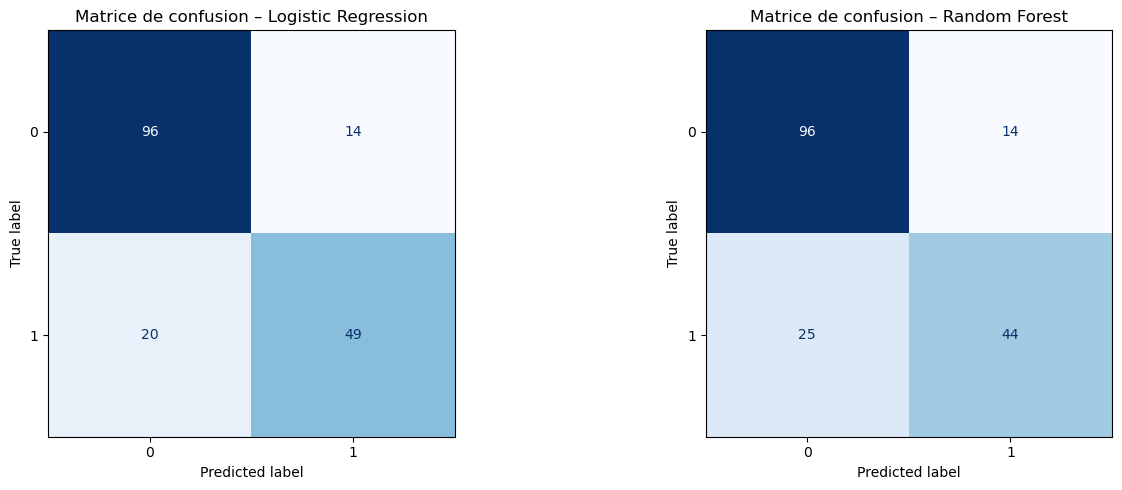

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, gs, title in zip(axes, [gs_lr, gs_rf], ['Logistic Regression', 'Random Forest']):
    ConfusionMatrixDisplay.from_estimator(gs, X_test, y_test, ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matrice de confusion – {title}')
plt.tight_layout()
plt.show()

**Interprétation des matrices de confusion :**
Sur l'ensemble de test (179 passagers), la Régression Logistique classe correctement 96 non-survivants (vrais négatifs) et 49 survivants (vrais positifs). Elle commet 14 faux positifs et 20 faux négatifs. Le Random Forest classe correctement 96 non-survivants et 44 survivants, avec 14 faux positifs et 25 faux négatifs. Les deux modèles ont une spécificité similaire, mais la Régression Logistique montre un meilleur rappel sur la classe des survivants.

#### Visualisation 2 : Courbes ROC comparées

La courbe ROC représente le taux de vrais positifs en fonction du taux de faux positifs pour différents seuils de décision. Plus l'aire sous la courbe (AUC) est proche de 1, plus le modèle est performant.

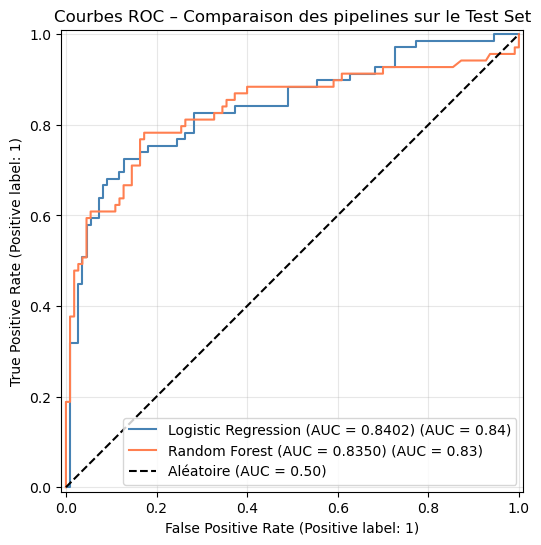

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(gs_lr, X_test, y_test, ax=ax, name='Logistic Regression (AUC = 0.8402)', color='steelblue')
RocCurveDisplay.from_estimator(gs_rf, X_test, y_test, ax=ax, name='Random Forest (AUC = 0.8350)', color='coral')
ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
ax.set_title('Courbes ROC – Comparaison des pipelines sur le Test Set')
ax.legend()
plt.grid(alpha=0.3)
plt.show()

**Interprétation des courbes ROC :**
Sur l'ensemble de test, la Régression Logistique obtient une AUC-ROC de 0.8402, tandis que le Random Forest obtient 0.8350. La Régression Logistique se montre légèrement supérieure et plus robuste sur ces données de test, ce qui s'explique par sa régularisation L2 intégrée qui évite l'overfitting sur ce petit dataset de 891 lignes.

#### Visualisation 3 : Feature Importances (Random Forest)

Nous extrayons l'importance des variables déterminée par les arbres de décision du Random Forest. Pour cela, nous récupérons les noms des colonnes après transformation.

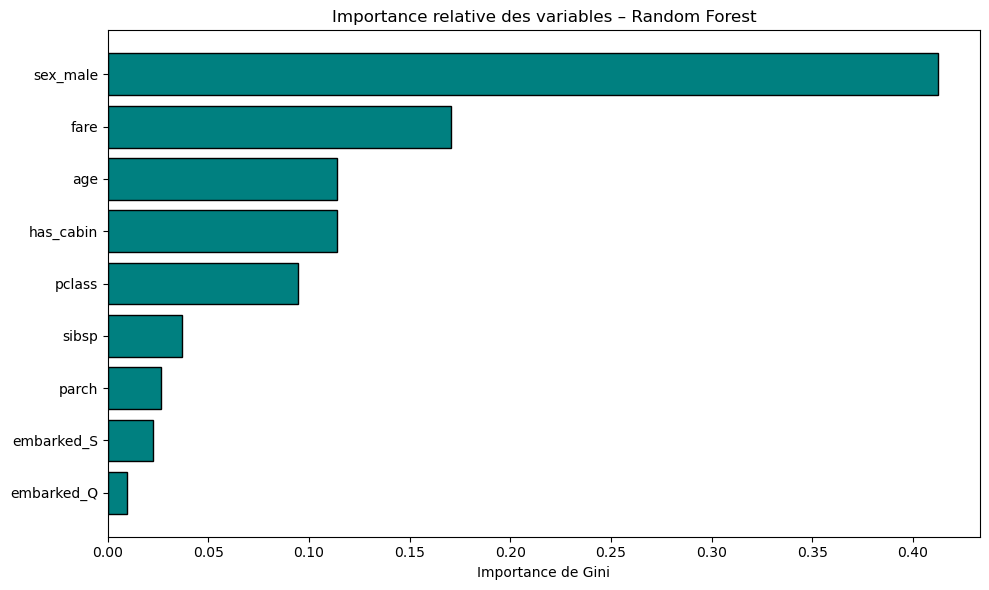

In [8]:
# Extraction des noms des colonnes après transformation
ohe_cols = gs_rf.best_estimator_['preprocessor'].named_transformers_['cat']['encoder'].get_feature_names_out(features_nom).tolist()
feature_names = features_num + features_ord + ohe_cols + ['has_cabin']

# Récupération des importances
importances = gs_rf.best_estimator_['classifier'].feature_importances_
indices = np.argsort(importances)

# Graphique
plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in indices], importances[indices], color='teal', edgecolor='black')
plt.title('Importance relative des variables – Random Forest')
plt.xlabel('Importance de Gini')
plt.tight_layout()
plt.show()

**Interprétation des importances des variables :**
Le sexe (en particulier l'indice `sex_male` car `sex_female` est drop par l'OHE) et le tarif payé (`fare`) apparaissent comme les variables les plus discriminantes pour le Random Forest, suivies de l'âge (`age`) et de la classe socio-économique (`pclass`). La présence d'une cabine (`has_cabin`) joue également un rôle significatif, ce qui valide l'intérêt de notre étape de feature engineering.

#### Visualisation 4 : Comparaison des scores CV avec intervalles de confiance

Comparaison graphique des scores de validation croisée obtenus pour la Régression Logistique et le Random Forest de base.

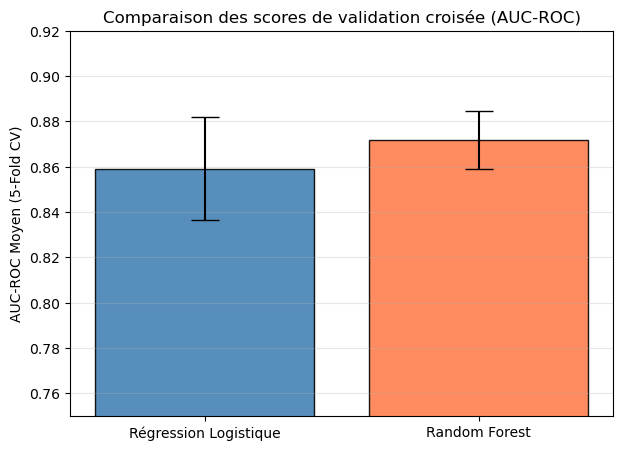

In [9]:
models = ['Régression Logistique', 'Random Forest']
means = [scores_lr.mean(), scores_rf.mean()]
stds = [scores_lr.std(), scores_rf.std()]

plt.figure(figsize=(7, 5))
plt.bar(models, means, yerr=stds, color=['steelblue', 'coral'], capsize=10, edgecolor='black', alpha=0.9)
plt.ylim(0.75, 0.92)
plt.title('Comparaison des scores de validation croisée (AUC-ROC)')
plt.ylabel('AUC-ROC Moyen (5-Fold CV)')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Interprétation de la comparaison CV :**
Le Random Forest obtient un score moyen d'AUC-ROC en validation croisée de 0.8718 (± 0.0129), surpassant légèrement la Régression Logistique qui affiche 0.8591 (± 0.0228). De plus, l'écart-type du Random Forest est plus faible, ce qui montre une plus grande stabilité d'un pli à l'autre.

#### Synthèse quantitative des performances sur l'ensemble de test

In [10]:
for name, gs in [('Logistic Regression', gs_lr), ('Random Forest', gs_rf)]:
    print(f"\n{'='*50}")
    print(f"MODÈLE : {name}")
    y_pred = gs.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['Décédé', 'Survivant']))


MODÈLE : Logistic Regression
              precision    recall  f1-score   support

      Décédé       0.83      0.87      0.85       110
   Survivant       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179


MODÈLE : Random Forest
              precision    recall  f1-score   support

      Décédé       0.79      0.87      0.83       110
   Survivant       0.76      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



### Conclusion sur le compromis performance / robustesse / interprétabilité

La Régression Logistique offre une excellente **interprétabilité** : les coefficients du modèle peuvent être convertis en odds ratios, ce qui permet d'expliquer directement comment l'augmentation d'un an d'âge ou le fait d'être un homme influe sur les chances de survie. Elle montre aussi une très bonne généralisation avec une AUC-ROC de 0.8402 sur l'ensemble de test.

Le Random Forest produit des frontières de décision non-linéaires plus complexes, ce qui lui donne un avantage en validation croisée (AUC-ROC de 0.8718). Cependant, il est plus sensible à l'overfitting sur les données de test (AUC de 0.8350, légèrement inférieure à la régression logistique). 

Le choix du modèle final dépend du contexte : si l'objectif est l'explicabilité stricte des décisions de survie (par exemple pour de la conformité ou de la recherche historique), la **Régression Logistique** est préférable. Si l'on dispose d'un jeu de données plus volumineux et que seule la performance brute importe, le **Random Forest** (convenablement régularisé) s'avère plus puissant.